# 08 [WIP]. which genes explain the lipid changes

*a spatial metabolomics primer · CAJAL neuromics summer school, Bordeaux 2026 · hands-on notebook*

By now you have measured what pregnancy does to the brain lipidome. You found the lipids that move,
you found the regions where they move most, and you painted the changes back onto the tissue. That is
a complete *description*. This notebook reaches for the next thing, a *mechanism*. Lipids are not made
by magic. Every lipid in a membrane was synthesised, remodeled, or degraded by an enzyme, and every
enzyme is a protein read off a gene. So if pregnancy reshapes the lipids of a region, somewhere in that
region the genes that build and break lipids are probably doing something different. The question of this
notebook is simple to state: which genes track the lipid change closely enough that we can call them
predictors?

We answer it with a second modality. From the Allen Brain Atlas we have a spatial transcriptome,
MERFISH, which counts individual gene transcripts inside individual cells, imputed up to 8460 genes and
averaged into every anatomical region. From your own pipeline we have the per-region pregnancy lipid
change, computed in a moment from the very `06_clustered.h5ad` you built in the clustering notebook. The
two datasets never touched the same tissue. They were measured in different mice, on different
instruments, in different labs. The only thing they share is a map. Both were registered into the same
Allen Common Coordinate Framework, so both speak in the same anatomical regions. That shared map is the
entire bridge. We line the two matrices up region by region, then ask a machine-learning model to learn,
from gene expression alone, where each lipid changes.

We meet that bridge at **two zoom levels of one gene-to-lipid question**. First, fine: for *every MSI
pixel* we borrow the genes and the cell type of the MERFISH *cells* that sit in the same little 3D ball,
built transparently with a KD-tree. Second, coarse: for *every Allen region* we join the
region-averaged transcriptome to the region's lipid change and let a model rank the gene programs. The
per-pixel view shows you the integration physically, pixel by pixel, and lets us ask which lipid
territories are also cell-type territories. The per-region view trades that resolution for statistics,
one clean number per region per gene, predictable by a tree. Same bridge, two zoom levels.

Here is the road:

> **integration by shared Allen coordinates -> per-pixel: a KD-tree ball query borrows MERFISH genes and
> a cell type for each MSI pixel, a gene map beside a lipid map, a cell-type territory map, and the
> lipizone x cell-type reciprocal enrichment -> per-region: the lipid-change matrix and the region x gene
> matrix, joined -> gradient-boosted trees (XGBoost), explained from scratch -> NMF gene programs as the
> features -> one regressor per lipid, scored by held-out Pearson r -> SHAP, which gene program drives
> each prediction -> the leading genes of the top program -> gene ontology of those genes -> a
> permutation null as the negative control -> the panels you assemble by hand into a figure.**

Every number and figure below comes from code that runs on *your* data: the two real sections you
carried through the course, one naive control and one pregnant, the same coronal plane, joined to the
real Allen MERFISH cells and the real Allen MERFISH region averages. These are your own lipizones, from
your own clustering, so your numbers will differ a little from a neighbour's, and that is exactly how a
real integrative analysis behaves. Nothing here is pre-cooked.

## the callouts

The four markers from the earlier notebooks carry through:

- 🔬 **TASK** something you do (write or run code).
- 💡 **HINT** a nudge when you are stuck.
- ❓ **QUESTION** pause and think, no code required.
- **check:** what you should see if it worked. If your screen disagrees, stop and fix it before moving on.

🔬 **TASK.** Run the next cell to load the stack. Everything here you met before, plus `xgboost` and
`shap` for the model, and `goatools` plus `mygene` for the gene ontology at the end.

In [1]:
# the scientific-Python stack you already know
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

# the new pieces for today: gradient-boosted trees, and SHAP for reading them
import xgboost as xgb
import shap

# the matrix factorisation, scaling and split helpers we lean on
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

# the small NMF fits below are short on purpose; silence the "max_iter reached" notices
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# the course helper package: the tested versions of the recipes we unroll
import cajal_lipidomics as cl
from cajal_lipidomics import multimodal, analysis, plotting
from cajal_lipidomics.style import set_style, FS
set_style()  # the lab figure style: clean, vector text, no top/right spines

# one global seed so every number and figure below is reproducible
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

print("ready. xgboost", xgb.__version__, "| shap", shap.__version__)

ready. xgboost 3.2.0 | shap 0.49.1


**check:** you should see `ready. xgboost ... | shap ...` and no red error. If a
`ModuleNotFoundError` appears, your notebook is on the wrong kernel: pick `cajal-lipidomics` from the
kernel picker (top right) and run this cell again.

## 1. the bridge: two experiments, one atlas

Hold this picture, because the whole notebook rests on it. We have two experiments.

The first is **your MALDI**, the data you have worked with all course. A laser walks across a tissue
section, fires at each tiny spot, and a mass spectrometer reports the abundance of every lipid at that
spot. One spot is one pixel. You have two sections, one control and one pregnant, and the
`06_clustered.h5ad` you built holds every pixel with its uMAIA-normalized lipid abundances, its Allen
region, and its lipizone, the lipid-defined cluster you found yourself.

The second is **Allen MERFISH**, a completely separate technology, run by a separate group, on separate
mice. MERFISH lights up individual RNA molecules inside individual cells under a microscope, so it
counts how many transcripts of each gene a cell holds. The Allen group imputed the measured panel up to
8460 genes and then averaged the gene counts inside every one of about 670 anatomical regions, giving
one number per gene per region.

There is **no pixel-to-cell correspondence** anywhere in this. A MALDI pixel was never matched to a
MERFISH cell, because they live in different brains. What saves us is registration. Both datasets were
warped into the **Allen Common Coordinate Framework**, the standard 3D mouse-brain atlas. The atlas
gives both modalities the *same 3D coordinates*, in millimetre-scale CCF units. A MALDI pixel has an
`(xccf, yccf, zccf)`, and so does every MERFISH cell, so the shared key can be as fine as physical
proximity in space or as coarse as the named region a coordinate falls in. That single fact buys us two
granularities, and we use both.

**Per-pixel (fine).** For each MALDI pixel we look up the MERFISH cells whose coordinates sit within a
small ball around it, and borrow them: average their gene counts, and take the majority cell type. This
hands every pixel an imputed gene-expression vector and a putative cell type, so we can lay a MERFISH
gene map beside a lipid map on the same tissue, and ask which lipid territories are also cell-type
territories. The cost is coverage: a pixel only gets borrowed genes where a MERFISH section actually
overlaps it, so not every pixel is matched.

**Per-region (coarse).** We collapse both modalities to the named Allen region: the per-region lipid
*change* upon pregnancy, and the region-averaged transcriptome. One number per region per gene, one per
region per lipid, joined on the region index. We lose the within-region detail but gain a clean, stable
table a model can learn from. This is the half that runs XGBoost, SHAP, and gene ontology.

The coarse move, in one line:

```
per-region lipid change   (region x lipid)        from your MALDI, control vs pregnant
per-region gene average   (region x gene)         from MERFISH
                  |  align on the region index  |
                  v                              v
        ask: do the genes of a region predict its lipid change?
```

This is exactly the integration strategy of the Lipid Brain Atlas, where the lipidome and the
transcriptome were joined through the Allen atlas and a model was asked which genes predict which
lipids. We do the pregnancy-specific version: the target is not the lipid level, it is the lipid
*change* upon pregnancy.

🔬 **TASK.** Load your clustered data, the output of the previous notebook. `adata.X` holds the
uMAIA-normalized lipid abundances, `adata.var` carries each ion's `lipid` annotation (some ions stay
unannotated and read `ion_...`), and `adata.obs` carries the metadata: `Condition` (naive control vs
pregnant), `acronym` (the Allen region of each pixel), and `lipizone` (your lipid-defined cluster).

In [2]:
# load YOUR clustered data: the end of the pipeline chain, not any pre-baked answer file
adata = ad.read_h5ad("../../data/derived/06_clustered.h5ad")

# a convenience map from each ion's var_name to its human-readable lipid annotation
ion_to_lipid = dict(zip(adata.var_names, adata.var["lipid"].astype(str)))
def nice(vn):  # friendly label for an ion, falling back to the var_name itself
    return ion_to_lipid.get(vn, vn)

print("pixels x ions:", adata.shape)
print("conditions:", dict(adata.obs["Condition"].value_counts()))
print("distinct Allen regions (acronym):", adata.obs["acronym"].nunique())
print("your lipizones:", adata.obs["lipizone"].nunique())
n_annot = int((~adata.var["lipid"].astype(str).str.startswith("ion_")).sum())
print("annotated lipids (of all ions):", n_annot, "of", adata.n_vars)
print("a few annotated lipids:", [l for l in adata.var["lipid"] if not l.startswith("ion_")][:6])

pixels x ions: (189011, 104)
conditions: {'pregnant': 100258, 'naive': 88753}
distinct Allen regions (acronym): 174
your lipizones: 18
annotated lipids (of all ions): 63 of 104
a few annotated lipids: ['LPC 15:1', 'LPE 21:1', 'PA 34:2', 'PA 34:1', 'PC 30:0', 'PA 36:2']


**check:** about `189011 x 104`, two conditions (`naive`, the control, and `pregnant`), 174
distinct Allen regions on this plane, and your own lipizones from the clustering notebook (a couple of
dozen of them). Of the 104 ions, the ones with a real lipid name are the ones we can interpret
chemically; the rest stay `ion_...` and are still perfectly usable as features. The differential side of
this notebook uses the uMAIA-normalized values directly, never the Harmony-corrected embedding:
Harmony's whole job is to make the two conditions overlap, so testing a condition difference on
Harmonized data would erase the very effect we want.

## 2. per-pixel integration: borrow genes from the nearest MERFISH cells

Before we collapse anything to regions, let us do the integration the *fine* way and watch it happen
pixel by pixel. The recipe is the heart of integration by shared coordinates, and it is far simpler
than it sounds once you see it unrolled.

We have two point clouds in the **same 3D Allen coordinate space**: your MALDI pixels at `(xccf, yccf,
zccf)`, and the Allen MERFISH cells at `(x_ccf, y_ccf, z_ccf)` (the underscore is the only naming
difference, the units are identical). For each MALDI pixel we ask a geometric question: *which MERFISH
cells sit within a small ball around me?* Take those neighbouring cells, average their 500 measured gene
counts, and take the majority vote of their cell type. That gives each pixel an imputed gene vector and
a putative cell type, borrowed from the transcriptome that happens to overlap it in space.

The only piece of machinery is a **cKDTree**, a binary space-partitioning tree from `scipy.spatial`. You
feed it the 3D coordinates of all the MERFISH cells once; it organises them so that a "give me every
point within radius r of this query point" lookup costs about `O(log N)` instead of scanning all cells.
That single trick, the ball query, is what makes matching ~190,000 pixels against hundreds of thousands
of cells feasible. Everything else is averaging and voting.

🔬 **TASK.** Load the per-cell MERFISH for this plane. The helper reads only the cells inside our AP
(`x_ccf`) window with a small buffer, keeps the 3D coordinates, the Allen cell-type columns
(`division`/`class`/`subclass`/`supertype`), and the 500 measured-gene columns (Ensembl transcript IDs
like `ENSMUST...`), and drops the vascular and immune cells we never want to match to.

💡 **HINT.** Every helper we call below lives in one readable file, `src/cajal_lipidomics/multimodal.py`. Before you run a helper, open that file and read the function so you know exactly what you are running. Start with `load_merfish_cells`: it is a thin reader that filters the parquet to the AP window, splits off the gene columns, and drops the divisions you do not want. Nothing magic, and now you can see that for yourself.

In [3]:
# the per-cell MERFISH: one row per Allen MERFISH cell, in the SAME CCF coordinate space
from cajal_lipidomics import multimodal as M

# the AP window: our MSI sections' x_ccf span, with a small buffer so we don't clip edge cells
ap = (float(adata.obs.xccf.min()) - 0.1, float(adata.obs.xccf.max()) + 0.1)
print(f"AP (x_ccf) window for the MSI plane: {ap[0]:.2f} .. {ap[1]:.2f}")

merfish_path = "../../data/merfish_plane.parquet"
cells, gene_cols = M.load_merfish_cells(merfish_path, ap)
print("MERFISH cells x columns:", cells.shape, "| measured genes:", len(gene_cols))
print("cell-type subclasses present:", cells["subclass"].nunique())
print("coordinate ranges agree? cells z_ccf",
      f"[{cells.z_ccf.min():.2f}, {cells.z_ccf.max():.2f}]  pixels zccf",
      f"[{adata.obs.zccf.min():.2f}, {adata.obs.zccf.max():.2f}]")

AP (x_ccf) window for the MSI plane: 5.98 .. 7.08


MERFISH cells x columns: (424183, 507) | measured genes: 500
cell-type subclasses present: 186
coordinate ranges agree? cells z_ccf [0.60, 10.79]  pixels zccf [0.67, 10.62]


**check:** you loaded a few hundred thousand MERFISH cells with 500 gene columns, and the cells'
`z_ccf`/`y_ccf` ranges overlap the pixels' `zccf`/`yccf` ranges. That overlap is the whole prerequisite:
if the two clouds did not share space, no ball would ever contain a cell.

🔬 **TASK.** Now unroll the matching for ONE pixel, by hand, so the helper is no black box. We build a
KD-tree on the cell coordinates, pick a single pixel, query every cell within 50 um (radius 0.05 in
CCF units, since 1 CCF unit is about 1 mm), the exact radius the paper uses, and average their genes
and vote their cell type.

In [4]:
# unroll the cKDTree ball query for ONE pixel
from scipy.spatial import cKDTree

cell_xyz = cells[["x_ccf", "y_ccf", "z_ccf"]].to_numpy()   # the MERFISH point cloud
tree = cKDTree(cell_xyz)                                    # build the tree once

RADIUS_PAPER = 0.05   # ~50 um in CCF units, the exact 3D radius the Lipid Brain Atlas uses

# pick one MSI pixel that actually has neighbours at the paper radius, so the demo is concrete
qall = adata.obs[["xccf", "yccf", "zccf"]].to_numpy()
pix = next((i for i in range(0, qall.shape[0], 37)
            if tree.query_ball_point(qall[i], r=RADIUS_PAPER)), 1000)
q = qall[pix]
nbrs = tree.query_ball_point(q, r=RADIUS_PAPER)            # indices of cells inside the ball
print(f"pixel {pix} at CCF {np.round(q, 2)} has {len(nbrs)} MERFISH cells within 50 um")

if nbrs:
    G = cells[gene_cols].to_numpy(np.float32)
    borrowed_genes = G[nbrs].mean(0)                        # average their 500 genes
    ct = cells["subclass"].astype(str).to_numpy()
    vals, counts = np.unique(ct[nbrs], return_counts=True)
    majority = vals[counts.argmax()]                        # majority-vote the cell type
    print("borrowed gene vector length:", borrowed_genes.shape[0])
    print("majority cell-type subclass in the ball:", majority)


pixel 0 at CCF [6.52 0.35 4.91] has 5 MERFISH cells within 50 um


borrowed gene vector length: 500
majority cell-type subclass in the ball: 287 Astro-TE NN


💡 **HINT.** That is the entire algorithm: one tree, one ball query per pixel, an average and a
vote. The helper `cl.multimodal.match_pixels_to_cells` does exactly this for *every* pixel at once,
returning a pixel x gene DataFrame (NaN where no cell was in the ball) and a per-pixel cell-type Series.
We run it at **radius 0.1** (about 100 um) rather than the paper's 0.05, and the next check explains
the honest reason why.

🔬 **TASK.** Match all pixels. This is a few seconds: one KD-tree, one vectorised ball query.

💡 **HINT.** Open `src/cajal_lipidomics/multimodal.py` and read `match_pixels_to_cells` now: it is the exact cKDTree ball query you just unrolled by hand, vectorised over all pixels. Reading it is how you confirm the helper does nothing you did not already do one pixel at a time.

In [5]:
# the helper does the unrolled match for EVERY pixel: average genes + majority-vote cell type
# first, the honest coverage at the paper's 50 um radius...
gdf50, _ = M.match_pixels_to_cells(adata.obs, cells, gene_cols, radius=0.05)
cov50 = float(gdf50.notna().any(axis=1).mean())

# ...then the radius we actually use, 100 um, for fuller coverage
gdf, celltype = M.match_pixels_to_cells(adata.obs, cells, gene_cols, radius=0.1)
cov = float(gdf.notna().any(axis=1).mean())

print(f"pixels matched at 50 um (r=0.05): {cov50:6.1%}")
print(f"pixels matched at 100 um (r=0.10): {cov:6.1%}")
print("per-pixel gene matrix:", gdf.shape, "| cell types assigned:", int(celltype.notna().sum()))


pixels matched at 50 um (r=0.05):  39.1%
pixels matched at 100 um (r=0.10):  77.0%
per-pixel gene matrix: (189011, 500) | cell types assigned: 145604


**check:** be honest about the coverage. At the paper's 50 um radius only a fraction of pixels
match; at 100 um it rises. The shortfall is not a bug, it is geometry: our MALDI plane is a thin
continuous sheet, while the Allen MERFISH brain is a stack of *discrete* coronal sections with gaps
between them. Wherever our plane falls between two MERFISH sections, no cell sits close enough in the
third dimension and the pixel goes unmatched. Widening the ball to 100 um reaches into the nearest
neighbouring sections and recovers more pixels, at the mild cost of averaging cells a little farther
away. We use 0.1 for the maps below so the territories are fuller and easier to read.

❓ **QUESTION.** We just widened the radius from the paper's 50 to 100 um to lift coverage. What is the trade-off we
accepted? (Hint: a bigger ball borrows from cells farther away, which can blur a sharp anatomical
border, exactly the contamination a region-constrained version of this match would guard against.)

## 2.1 a MERFISH gene map beside a lipid map

The cleanest sanity check on the whole match is visual. If we borrowed genes correctly, then a **myelin
gene** should light up the **white matter**, the very same place a **myelin lipid** lights up. We put
them side by side. For the gene we use `ENSMUST00000102665`, the transcript of **`Mog`**, myelin
oligodendrocyte glycoprotein, a textbook oligodendrocyte/myelin marker, and the exact gene the Lipid
Brain Atlas overlaid on a HexCer to validate section quality. For the lipid we use **`HexCer 42:2`**,
the myelin sphingolipid that is the spine of this whole notebook, picked from your own annotated ions.

🔬 **TASK.** Paint the borrowed `Mog` transcript and the measured `HexCer 42:2` lipid on the same
sections, only on the matched pixels.

myelin lipid ion: C48H91NO8__+H -> HexCer 42:2


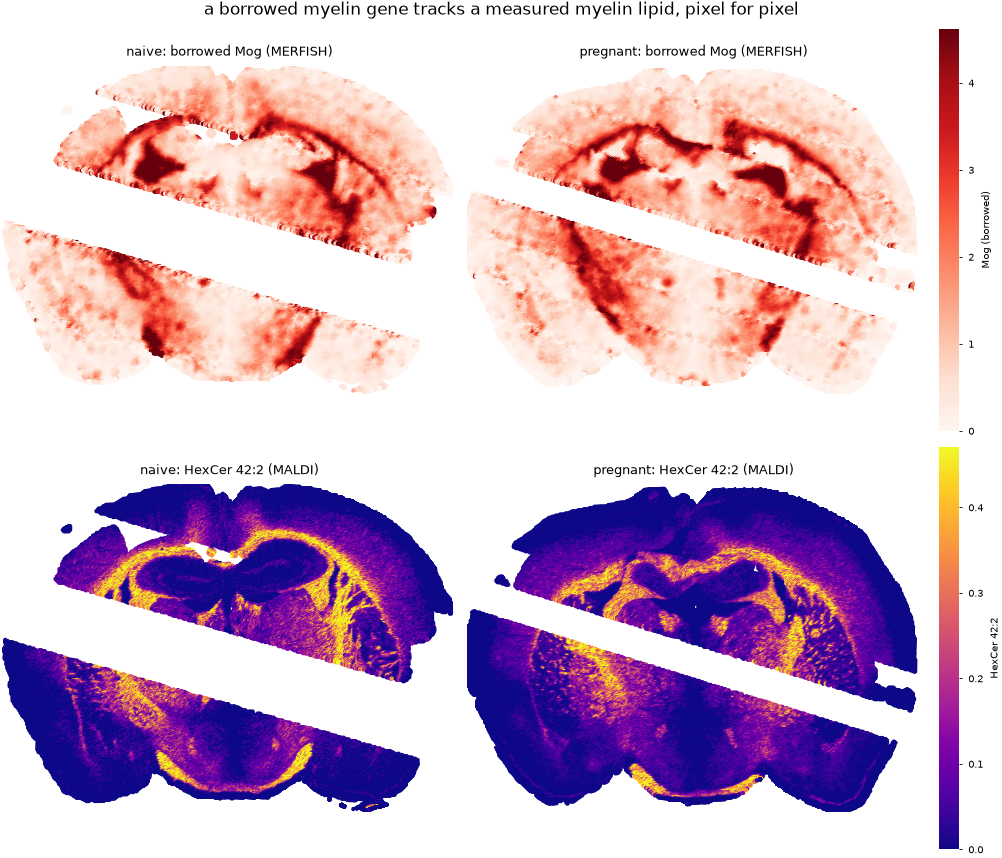

In [6]:
# a borrowed MERFISH myelin gene next to a measured myelin lipid, on matched pixels
MYELIN_GENE = "ENSMUST00000102665"     # transcript of Mog (myelin oligodendrocyte glycoprotein)

# find the ion whose annotation is the myelin sphingolipid HexCer 42:2 (your own data)
MYELIN_ION = next(vn for vn, l in ion_to_lipid.items() if l == "HexCer 42:2")
MYELIN_LIPID = nice(MYELIN_ION)
print("myelin lipid ion:", MYELIN_ION, "->", MYELIN_LIPID)

obs = adata.obs
gene_vec = gdf[MYELIN_GENE].to_numpy()                 # borrowed per-pixel gene (NaN where unmatched)
lipid_vec = np.asarray(adata[:, MYELIN_ION].X).ravel()
matched = ~np.isnan(gene_vec)

secs = sorted(obs["SectionID"].unique())
fig, axes = plt.subplots(2, len(secs), figsize=(4.2 * len(secs), 7.2), constrained_layout=True)
z, y = obs["zccf"].to_numpy(), -obs["yccf"].to_numpy()
for col, s in enumerate(secs):
    m = (obs["SectionID"] == s).to_numpy()
    cond = obs.loc[m, "Condition"].iloc[0]
    mm = m & matched
    g = gene_vec[mm]
    sc0 = axes[0, col].scatter(z[mm], y[mm], c=g, cmap="Reds", s=2.5, rasterized=True,
                               vmin=np.nanpercentile(gene_vec, 2), vmax=np.nanpercentile(gene_vec, 98))
    axes[0, col].set_title(f"{cond}: borrowed Mog (MERFISH)", fontsize=FS["s"])
    lv = lipid_vec[mm]
    sc1 = axes[1, col].scatter(z[mm], y[mm], c=lv, cmap="plasma", s=2.5, rasterized=True,
                               vmin=np.nanpercentile(lipid_vec[matched], 2),
                               vmax=np.nanpercentile(lipid_vec[matched], 98))
    axes[1, col].set_title(f"{cond}: {MYELIN_LIPID} (MALDI)", fontsize=FS["s"])
    for ax in (axes[0, col], axes[1, col]):
        cl.style.spatial_axes(ax)
        ax.set_xlim(z.min(), z.max()); ax.set_ylim(y.min(), y.max())
cl.style.lightweight_colorbar(sc0, list(axes[0]), label="Mog (borrowed)")
cl.style.lightweight_colorbar(sc1, list(axes[1]), label=MYELIN_LIPID)
fig.suptitle("a borrowed myelin gene tracks a measured myelin lipid, pixel for pixel", fontsize=FS["m"])
plt.show()

**check:** the two rows light up the **same white-matter tracts**: the borrowed `Mog` transcript
(top, from MERFISH cells) and the measured `HexCer 42:2` lipid (bottom, from your MALDI) both trace the
fibre tracts on both sections. That co-localisation is the per-pixel proof that the shared-coordinate
match worked: a gene and a lipid, measured in different mice on different instruments, agree on where
myelin is, because both were borrowed into the same CCF coordinates. This is the same gene-to-lipid
relationship the region-level XGBoost will quantify later, seen here as a raw picture.

## 2.2 the per-pixel cell-type territory map

The match handed each pixel not just genes but a **cell type**, the majority Allen `subclass` of the
MERFISH cells in its ball. Painting that gives a per-pixel cell-type *territory* map: where, on your
MALDI tissue, the transcriptome says oligodendrocytes, astrocytes, and the various neuron classes live.

🔬 **TASK.** Colour the matched pixels by their most common borrowed cell-type subclass, keeping the
handful of largest subclasses so the legend stays legible. We colour them with the course's
`distinct_colors` palette, so the territories read clearly rather than washing into one another.

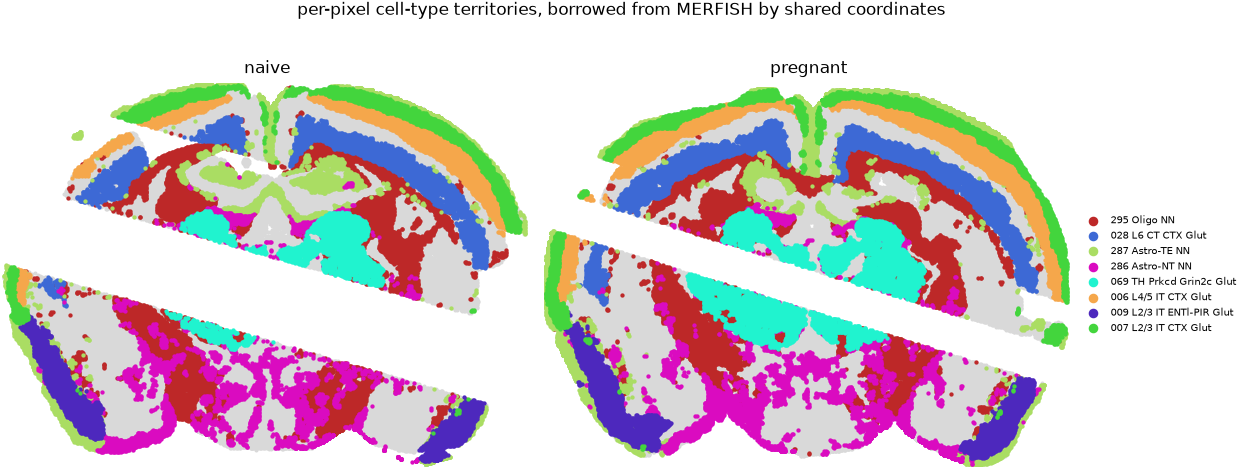

In [7]:
# per-pixel cell-type territories: colour each matched pixel by its majority MERFISH subclass
ct = celltype.copy()
top_ct = ct.value_counts().head(8).index.tolist()      # the 8 most common subclasses, for a clean legend
ct_plot = ct.where(ct.isin(top_ct), other=np.nan)

# distinct, similarity-spread colours (the course palette), never a default categorical map
pal = plotting.distinct_colors(len(top_ct))
cmap_ct = {name: pal[i] for i, name in enumerate(top_ct)}

secs = sorted(obs["SectionID"].unique())
fig, axes = plt.subplots(1, len(secs), figsize=(5.2 * len(secs), 4.4), constrained_layout=True)
if len(secs) == 1:
    axes = [axes]
z, y = obs["zccf"].to_numpy(), -obs["yccf"].to_numpy()
for ax, s in zip(axes, secs):
    m = (obs["SectionID"] == s).to_numpy()
    bg = m & ct.notna().to_numpy() & ~ct_plot.notna().to_numpy()   # matched-but-not-top, faint grey
    ax.scatter(z[bg], y[bg], c="0.85", s=2.0, rasterized=True)
    for name in top_ct:
        sel = m & (ct_plot == name).to_numpy()
        if sel.any():
            ax.scatter(z[sel], y[sel], color=cmap_ct[name], s=2.5, rasterized=True, label=name)
    cl.style.spatial_axes(ax)
    ax.set_xlim(z.min(), z.max()); ax.set_ylim(y.min(), y.max())
    ax.set_title(obs.loc[m, "Condition"].iloc[0], fontsize=FS["m"])
axes[-1].legend(fontsize=FS["xs"], markerscale=3, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.suptitle("per-pixel cell-type territories, borrowed from MERFISH by shared coordinates", fontsize=FS["m"])
plt.show()

💡 **HINT.** The territories should be anatomically sensible: an oligodendrocyte subclass paints
the white-matter tracts, astrocyte subclasses fill the grey matter, and the neuron subclasses tile the
cortical and thalamic regions. Each colour is a *majority vote* of real MERFISH cells inside each
pixel's ball, so the map is the transcriptome's opinion of your tissue's cellular composition.

**check:** you should see coherent coloured territories, not random speckle. The oligodendrocyte
territory overlapping the same tracts as the `Mog`/`HexCer` map above is the consistency check: genes,
lipid, and cell type all agree on where the white matter is.

## 2.3 which lipid territories are also cell-type territories

Each pixel now carries two independent labelings: a **lipizone** (its lipid-defined cluster, from your
clustering notebook, in `obs.lipizone`) and a **cell type** (its borrowed MERFISH subclass). The natural
multimodal question is colocalisation: *which lipizones occupy the same tissue as which cell types?* We
answer it with **reciprocal enrichment**, the metric from the Lipid Brain Atlas.

The idea is a doubly-normalised crosstab. Count co-occurring pixels in a lipizone x cell-type table.
Normalise once down the columns and divide by the mean, giving how enriched each cell type is within
each lipizone. Normalise the transpose the same way, giving how enriched each lipizone is within each
cell type. Multiply the two element-wise. A pair scores high only when the lipizone is unusually full of
that cell type *and* the cell type is unusually full of that lipizone, a *reciprocal* agreement that is
robust to one side simply being large. The helper `cl.multimodal.reciprocal_enrichment` does exactly
this, and only this: a doubly-normalised crosstab multiplied element-wise. The scores span orders of magnitude, but we display them raw, with the colour limits at the 2nd and 98th percentiles (never on a log scale, as the docstring says).

🔬 **TASK.** Build the lipizone x cell-type reciprocal-enrichment matrix on the matched pixels, then
show it as a heatmap.

💡 **HINT.** Before you trust the heatmap, open `src/cajal_lipidomics/multimodal.py` and read `reciprocal_enrichment`. You will see it is *not* a plain crosstab: it normalises both directions and multiplies them, so a pair scores high only when each category is enriched in the other. That is the whole reason a small lipizone can still light up against a small cell type.

reciprocal-enrichment matrix (lipizones x cell-type subclasses): (18, 105)


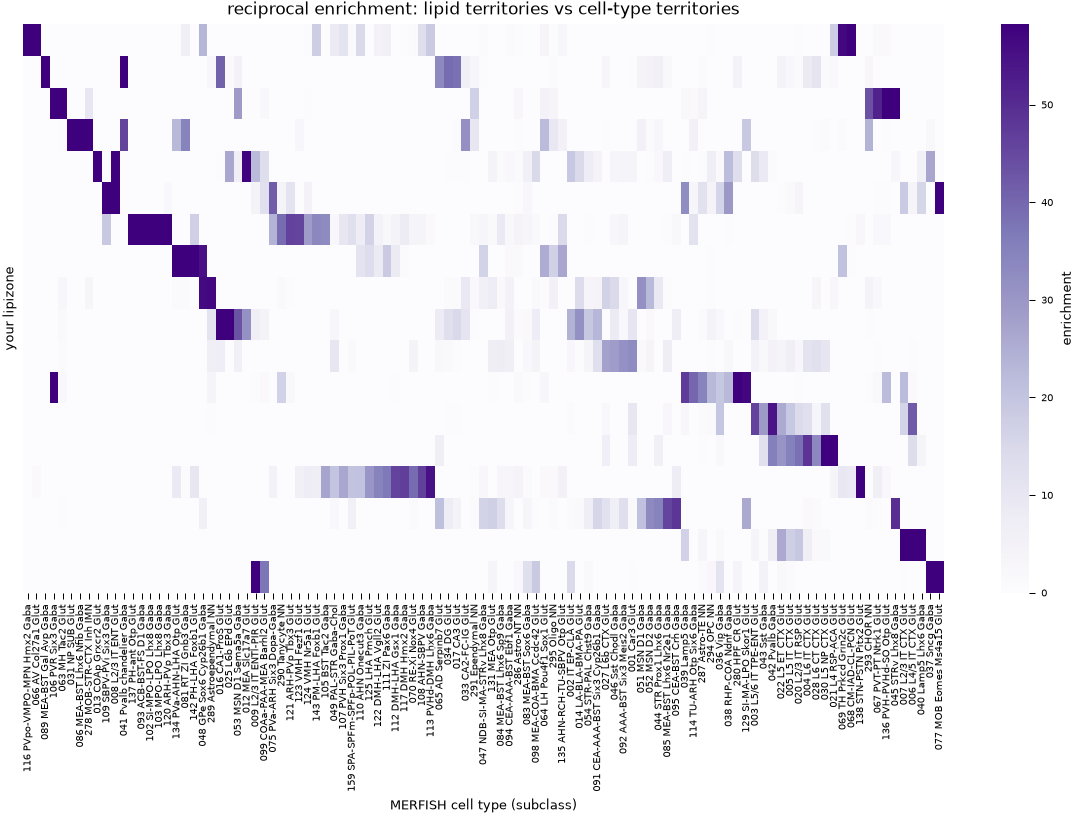

In [8]:
# reciprocal enrichment between YOUR lipid-defined lipizones and the borrowed cell types,
# unrolled exactly as in notebook 6 (two crosstabs -> enrichments -> product); same recipe as the LBA.
from scipy.cluster import hierarchy as sch
both = adata.obs.loc[celltype.notna()].copy()
lip = both["lipizone"].astype(str); ct = celltype[celltype.notna()].astype(str)

c1 = pd.crosstab(lip, ct); n1 = c1 / c1.sum(); n1 = (n1.T / n1.T.mean()).T   # cell type enriched in lipizone
c2 = pd.crosstab(ct, lip); n2 = c2 / c2.sum(); n2 = (n2.T / n2.T.mean()).T   # lipizone enriched in cell type
enr = n1 * (n2.T)                                                            # reciprocal, lipizone x cell type

# order columns by hierarchical clustering, rows by argmax (clean near-diagonal blocks)
col_order = sch.leaves_list(sch.linkage(sch.distance.pdist(enr.T), method="weighted", optimal_ordering=True))
enr = enr.iloc[:, col_order]
enr = enr.iloc[np.argsort(np.argmax(enr.values, axis=1)), :]
print("reciprocal-enrichment matrix (lipizones x cell-type subclasses):", enr.shape)

# Luca's display: raw enrichment, vmin/vmax at the 2nd/98th percentiles (NO log scale), Purples
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(enr, cmap="Purples", cbar_kws={"label": "enrichment"}, xticklabels=True, yticklabels=False,
            vmin=np.percentile(enr.values, 2), vmax=np.percentile(enr.values, 98))
plt.xlabel("MERFISH cell type (subclass)"); plt.ylabel("your lipizone"); 
plt.title("reciprocal enrichment: lipid territories vs cell-type territories")
plt.tight_layout(); plt.show()

The enrichment matrix says which lipizone matches which cell type. Make it concrete: take the few
strongest matches and look at them **in space side by side**, the lipizone in red and the matched cell type
in blue. If the integration is real, the two should paint the same territory.

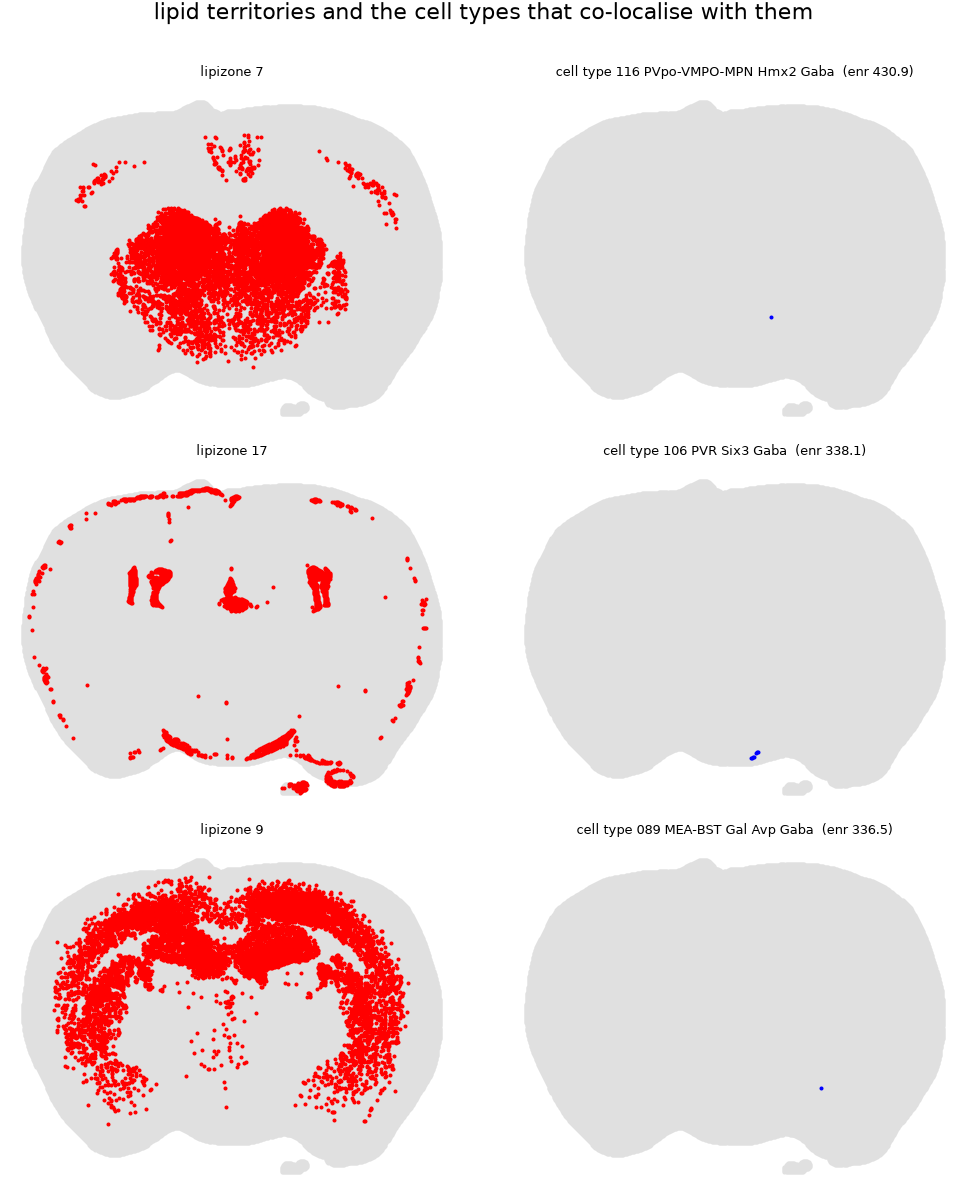

In [9]:
# strongest lipizone <-> cell-type matches, shown in space side by side
pairs = sorted([(lz, enr.columns[enr.loc[lz].values.argmax()], float(enr.loc[lz].max())) for lz in enr.index],
               key=lambda t: -t[2])[:3]
xx, yy = adata.obs['x'].to_numpy(), -adata.obs['y'].to_numpy()
fig, axes = plt.subplots(len(pairs), 2, figsize=(8.5, 3.3*len(pairs)))
for r,(lz,ct,val) in enumerate(pairs):
    m_lz = (adata.obs['lipizone'].astype(str)==str(lz)).to_numpy()
    m_ct = (celltype.astype(str)==str(ct)).to_numpy()
    for col,(mask,color,name) in enumerate([(m_lz,'red',f'lipizone {lz}'),(m_ct,'blue',f'cell type {ct}')]):
        ax=axes[r,col]; ax.scatter(xx,yy,c='0.88',s=2,rasterized=True); ax.scatter(xx[mask],yy[mask],c=color,s=2,rasterized=True)
        ax.set_aspect('equal'); ax.axis('off'); ax.set_title(name + (f'  (enr {val:.1f})' if col else ''), fontsize=8)
plt.suptitle('lipid territories and the cell types that co-localise with them', y=1.01); plt.tight_layout(); plt.show()

**check:** the heatmap is *blocky*, not uniform: most lipizones light up against one or a few
cell types, the bright cells showing lipizone-to-cell-type pairs that co-occupy the same tissue far more
than chance. That structure is the per-pixel multimodal payoff: a lipid-defined territory is, very
often, also a cell-type territory, because the cells that build a region's membranes shape its lipidome.
This is the same gene-to-lipid logic as the region-level model, read at single-pixel resolution and
phrased in cell types rather than gene programs.

❓ **QUESTION.** A lipizone that lights up strongly against the oligodendrocyte subclass is, in effect, a
white-matter lipid signature. How does that connect to the `Mog`/`HexCer 42:2` map two cells above, and
to the *myelination* gene program XGBoost will surface at the region level later? (They are three views
of one biology: oligodendrocytes, myelin genes, myelin lipids.)

---

We have now done the integration the fine way and seen it physically: a borrowed gene map, a cell-type
territory map, and a lipizone x cell-type colocalisation. The rest of the notebook does the *same*
gene-to-lipid question at the coarser region granularity, where one number per region per gene lets a
gradient-boosted model rank gene *programs* and gene ontology *name* them. Two zoom levels, one bridge.

## 3. build the per-region lipid-change matrix

Our statistical unit changes here. Until now a pixel was a unit. But a single MERFISH region average is
one number per gene, so to line the two modalities up we must also reduce each lipid to one number per
region: the **pregnancy fold change** of that lipid in that region.

The recipe is the simplest thing that could work, and we unroll it so nothing hides. Inside one Allen
region, take all the control pixels and average each lipid; take all the pregnant pixels and average
each lipid; then report the change as a log2 fold change, `log2(pregnant_mean / control_mean)`. A log2FC
of `+1` means the lipid doubled, `-1` means it halved, `0` means no change. We use log2 because it is
symmetric: a doubling and a halving are `+1` and `-1`, equal and opposite, which a raw ratio of 2 versus
0.5 would not give you.

One guard matters. A region with three control pixels and two pregnant pixels gives a meaningless
average, so we keep only regions with at least 50 pixels in *both* conditions. That keeps the
statistical units honest.

🔬 **TASK.** Build the change for one region by hand first, so the helper that follows is no longer a
black box. We pick the caudoputamen, `CP`, the big striatal region on this plane.

In [10]:
# unroll the per-region change for ONE region, by hand
X = np.asarray(adata.X)              # pixels x ions
obs = adata.obs
ions = list(adata.var_names)
eps = 1e-11                          # avoids log2(0); the smallest of nudges

reg = "CP"                           # caudoputamen (striatum), a large region on this plane
in_reg = (obs["acronym"] == reg).to_numpy()
is_ctrl = in_reg & (obs["Condition"] == "naive").to_numpy()
is_preg = in_reg & (obs["Condition"] == "pregnant").to_numpy()
print(f"{reg}: {is_ctrl.sum()} control pixels, {is_preg.sum()} pregnant pixels")

mean_ctrl = X[is_ctrl].mean(0) + eps         # mean of each lipid in control pixels of CP
mean_preg = X[is_preg].mean(0) + eps         # mean of each lipid in pregnant pixels of CP
log2fc_cp = np.log2(mean_preg / mean_ctrl)   # one log2 fold change per lipid

# the three lipids that move most in this region
order = np.argsort(np.abs(log2fc_cp))[::-1][:3]
for j in order:
    print(f"  {nice(ions[j]):>18s}  log2FC = {log2fc_cp[j]:+.2f}")

CP: 5788 control pixels, 7829 pregnant pixels
         ion_443:233  log2FC = +19.93
             PG 38:1  log2FC = -18.86
             PG 40:1  log2FC = -17.63


💡 **HINT.** The sign tells the direction. A positive log2FC means the lipid is *higher* in the
pregnant brain in that region; negative means lower. The magnitude is how big the change is on a
doubling scale.

That hand-built vector, one log2FC per ion for one region, is exactly one row of the matrix we want. The
helper `cl.multimodal.region_change_matrix` does this for every region at once, keeping only regions
with at least 50 pixels per condition, and returns a tidy region x ion table.

In [11]:
# the helper does exactly what we just did, for every region at once
# (open src/cajal_lipidomics/multimodal.py and read region_change_matrix before you trust it)
change = multimodal.region_change_matrix(
    adata, region_key="acronym", cond_key="Condition",
    control="naive", case="pregnant", min_pixels=50,
)
print("region x ion change matrix:", change.shape)

# confirm our hand-built CP row matches the helper's CP row
hand = pd.Series(log2fc_cp, index=ions)
auto = change.loc["CP"]
print("max abs difference (hand vs helper):", float((hand - auto).abs().max()))
change.iloc[:5, :4]

region x ion change matrix: (125, 104)
max abs difference (hand vs helper): 0.0


,C23H46NO7P__+K,C24H50NO7P__+K,C25H44NO7P__+K,C25H50NO7P__+K
AIp1,-3.047629,-2.532597,-1.949448,0.000000
AIp2/3,-1.078980,-0.146431,0.118798,0.682171
AIp5,-0.618023,0.348321,0.302336,1.251171
AIp6a,-0.381101,0.627850,0.506904,1.116149
ARH,-0.698003,0.436818,0.632942,-0.452983


**check:** the matrix is roughly `120 x 104`: the regions that survived the 50-pixel gate, each
with its 104 ion changes. The max difference between our hand-built CP row and the helper's is
essentially zero (floating-point dust), so the helper is doing precisely what we did by hand.

## 4. bring in the genes and join on the region

Now the other modality. The file `avemerfish_imputed_named.parquet` is the Allen MERFISH transcriptome,
imputed to 8460 genes and **averaged inside each Allen region**. Its row index is the Allen acronym, the
exact same key our change matrix uses, and its columns are real mouse gene symbols, things like `Pparg`
and `Mobp`, which we will later hand straight to the gene ontology.

🔬 **TASK.** Load it and look at its shape.

In [12]:
# region x gene matrix: Allen MERFISH-imputed expression averaged per region
genes_all = pd.read_parquet(
    "../../data/avemerfish_imputed_named.parquet"
)
print("region x gene matrix:", genes_all.shape)
print("first regions:", list(genes_all.index[:4]))
print("a few genes:", list(genes_all.columns[:6]))
print("Pparg present?", "Pparg" in genes_all.columns, "| Mobp present?", "Mobp" in genes_all.columns)

region x gene matrix: (670, 8460)
first regions: ['AAA', 'ACAd1', 'ACAd2/3', 'ACAd5']
a few genes: ['Ccdc3', 'Grp', 'Nos1', 'Otof', 'Dach1', 'Arhgef28']
Pparg present? True | Mobp present? True


The join is an inner intersection on the region index: keep only the regions that appear in
*both* matrices. Some Allen regions are in your lipid plane but not in the MERFISH coverage, and vice
versa, so the intersection is smaller than either. The helper `cl.multimodal.join_genes` does the
intersection and returns the two matrices aligned row for row.

🔬 **TASK.** Join the two matrices.

In [13]:
# align the lipid-change matrix and the gene matrix on shared regions
change, genes = multimodal.join_genes(change, genes_all)

print("aligned change matrix:", change.shape, "  aligned gene matrix:", genes.shape)
print("same region order?", (change.index == genes.index).all())
print("number of shared regions:", len(change))

aligned change matrix: (111, 104)   aligned gene matrix: (111, 8460)
same region order? True
number of shared regions: 111


**check:** both matrices now have the same number of rows (about 100-110 shared regions) in the
same order. Those regions are our training and test examples: each region is one observation with 8460
gene features and 104 ion-change targets.

❓ **QUESTION.** We have around a hundred regions and 8460 genes. That is far more features than
examples, the classic "wide" problem where a model can memorise the training rows perfectly and learn
nothing. Keep this in mind: it is exactly why, in a moment, we compress the 8460 genes into a handful of
programs before we let any model see them.

## 5. gradient-boosted trees, from the ground up

We are about to ask a model to predict each lipid's change from gene expression. The model is
**XGBoost**, gradient-boosted decision trees. The name sounds heavy; the idea is light, and you should
hold it before pressing the button.

Start with a **decision tree**. A tree is a flowchart of yes/no questions on the features. "Is the
expression of gene A above 0.3? If yes, go left; if no, go right." Each answer sends you down a branch,
and at the bottom, the leaf, the tree predicts a number, usually the average target of the training
examples that landed there. A single tree is easy to read but weak: it carves the feature space into
boxes and predicts a flat value in each box, so it is blocky and it overfits if grown deep.

**Boosting** turns many weak trees into one strong predictor, and the trick is that the trees are not
independent. You fit the first tree. It is wrong by some amount on every example, and those errors are
called residuals. You then fit a *second* tree, not to the target, but to the residuals of the first, so
the second tree's only job is to fix what the first got wrong. You add a small fraction of the second
tree's correction (the learning rate, often 0.05, keeps each step humble), and you repeat. Hundreds of
small trees, each patching the leftover error of all the trees before it, sum to a model that bends
smoothly to the data. That sequential error-correction is "gradient boosting": each tree steps in the
direction that most reduces the error, the gradient of the loss.

Why XGBoost rather than a straight line? Because the link from genes to lipids is not a straight line. A
lipid might rise with a gene only past a threshold, or rise with gene A only when gene B is also high.
Trees catch thresholds and interactions for free, because every split is a threshold and every path down
the tree is a conjunction of conditions. The cost is that trees, left alone, overfit, so we lean on a
few guardrails: shallow trees (`max_depth=3`, so each tree asks at most three questions), row and column
subsampling (each tree sees only 80% of the regions and 80% of the features, which decorrelates them),
and an L2 penalty (`reg_lambda`) that shrinks leaf predictions toward zero.

🔬 **TASK.** Watch boosting work on a toy before we use it for real. We make a wiggly 1D function, hide
it under noise, and fit XGBoost with 1, 5, and 200 trees so you can see the prediction sharpen as trees
accumulate.

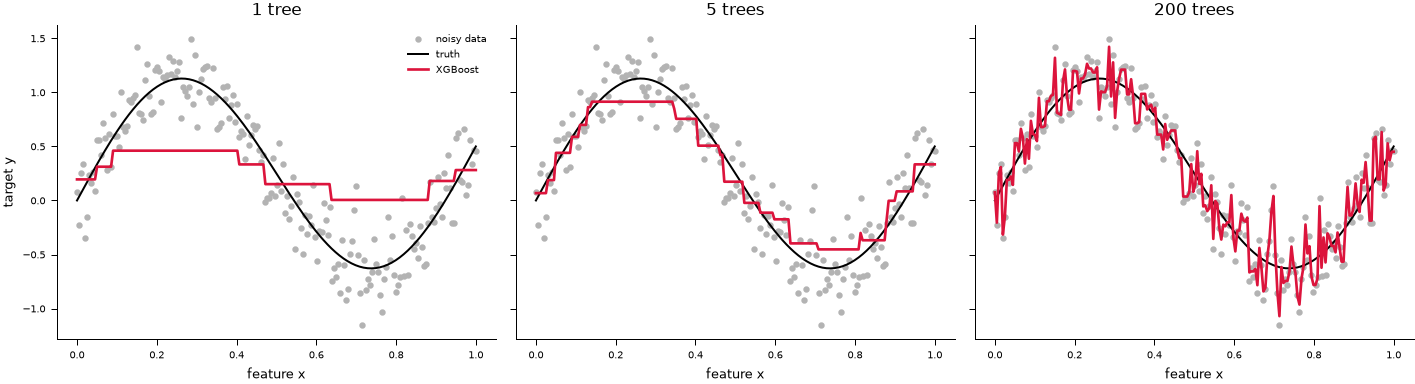

In [14]:
# a toy 1D regression to SEE boosting accumulate
x_toy = np.linspace(0, 1, 200)
true = np.sin(2 * np.pi * x_toy) + 0.5 * x_toy        # the wiggly truth
y_toy = true + rng.normal(0, 0.25, size=x_toy.size)   # observed = truth + noise
Xt = x_toy.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, n_trees in zip(axes, [1, 5, 200]):
    m = xgb.XGBRegressor(n_estimators=n_trees, learning_rate=0.3, max_depth=3,
                         random_state=SEED, objective="reg:squarederror")
    m.fit(Xt, y_toy)
    ax.scatter(x_toy, y_toy, s=8, c="0.7", rasterized=True, label="noisy data")
    ax.plot(x_toy, true, c="k", lw=1.2, label="truth")
    ax.plot(x_toy, m.predict(Xt), c="crimson", lw=1.6, label="XGBoost")
    ax.set_title(f"{n_trees} tree{'s' if n_trees > 1 else ''}", fontsize=FS["m"])
    ax.set_xlabel("feature x")
axes[0].set_ylabel("target y")
axes[0].legend(fontsize=FS["xs"])
plt.tight_layout(); plt.show()

**check:** one tree is a crude staircase. Five trees already curve. Two hundred trees trace the
wiggly truth without chasing every noisy point: that is boosting, many humble steps adding up to a
flexible fit. Now we point the same machine at our real biology.

❓ **QUESTION.** The 200-tree fit follows the truth but stays smoother than the noise. Which two
guardrails in the model object are buying us that smoothness rather than a fit that threads every grey
dot? (Hint: depth, and how big a step each tree is allowed to take.)

## 6. NMF gene programs as the features

We will not feed 8460 raw genes to XGBoost. With only about a hundred regions, that is hopeless: the
model would have 8460 knobs to fit a hundred numbers and would memorise noise. We compress the genes
first, exactly as the early notebook taught with NMF on lipids, now applied to genes.

Non-negative matrix factorisation finds a small set of **gene programs**. Each program is a recipe of
co-expressed genes, a non-negative weight for every gene, and each region is described by how strongly
it expresses each program. Formally NMF factors the region x gene matrix `V` into two non-negative
matrices, `V ~ W . H`:

- **W** is region x program: how active each gene program is in each region. This becomes our feature
  matrix, 20 numbers per region instead of 8460.
- **H** is program x gene: the recipe of each program, the gene loadings. This is what we read at the
  end to say *which genes* a predictive program is made of.

Non-negativity is the point. Genes are counted, never negative, so a program can only *add* genes
together, never cancel one against another. The programs come out as coherent co-expression modules you
can name, the way the early notebook's lipid programs came out as the sphingolipid program and the
membrane-phospholipid program.

🔬 **TASK.** Unroll the program construction so the helper is transparent. NMF needs non-negative input
on a comparable scale, so we MinMax-scale each gene to [0, 1] first, then fit 20 programs.

In [15]:
# unroll: MinMax each gene to [0,1] (NMF needs >=0), then factor into 20 programs
N_PROGRAMS = 20
Xg = MinMaxScaler().fit_transform(genes.values)          # regions x genes, in [0,1]
nmf = NMF(n_components=N_PROGRAMS, init="nndsvda", random_state=SEED, max_iter=500)
W = nmf.fit_transform(Xg)        # regions x programs : program activity per region
H = nmf.components_              # programs x genes    : gene recipe of each program

print("V (regions x genes):", Xg.shape)
print("W (regions x programs):", W.shape)
print("H (programs x genes):", H.shape)
print("all non-negative?", (W >= 0).all() and (H >= 0).all())

V (regions x genes): (111, 8460)
W (regions x programs): (111, 20)
H (programs x genes): (20, 8460)
all non-negative? True


The helper `cl.multimodal.gene_programs` does exactly this MinMax-then-NMF and returns `W`, `H`,
and the fitted model. We call it so the rest of the notebook uses the canonical objects.

💡 **HINT.** Open `src/cajal_lipidomics/multimodal.py` and read `gene_programs`: it is the five lines you just ran, no more. Same habit for `predict_changes` and `top_genes_for_program` further down, the two helpers that fit the trees and read out the leading genes.

In [16]:
# the helper does exactly the MinMax + NMF above
W, H, nmf_model = multimodal.gene_programs(genes, n_programs=N_PROGRAMS, random_state=SEED)
# NOTE: these programs are fit on ALL regions, just to SEE what a program looks like. The
# held-out predictive test below refits programs on the training regions only (no leakage).
print("W", W.shape, "| H", H.shape)

# look at one program's recipe: its 10 leading genes
prog0 = pd.Series(H[0], index=genes.columns).sort_values(ascending=False)
print("\nprogram1 leading genes:", list(prog0.head(10).index))

W (111, 20) | H (20, 8460)

program1 leading genes: ['Teddm3', 'Tshz2', 'Lamc2', 'Tnnt2', '5530401A14Rik', 'Hunk', 'Dpp4', '1810034E14Rik', 'Gm16294', 'Cldn22']


💡 **HINT.** Each program is a soft module of genes that rise and fall together across regions. A
program is interpretable to the extent its leading genes share a biology, and that is precisely what the
gene ontology step at the end will test, formally.

**check:** `W` is about `(regions x 20)` and `H` is `(20 x 8460)`. We turned 8460 gene features into 20
program features. The model now has a fighting chance against a hundred examples.

## 7. one regressor per lipid, scored honestly

Now the core. For each of the 104 ions we train one XGBoost regressor that predicts that ion's
per-region change from the 20 gene programs. To know whether the model actually learned, we must score
it on regions it never trained on, so we split the regions once into a training set and a held-out test
set, and we reuse the same split for every ion. The score is the **Pearson correlation** between the
predicted change and the true change on the test regions. A Pearson r near 1 means the gene programs
predict where that lipid moves; near 0 means they do not.

🔬 **TASK.** Unroll the loop for ONE lipid first, end to end, so the per-lipid helper is no longer
opaque. We z-score the program activities (so each program enters on a comparable scale), split the
regions, fit, predict, and correlate. We pick whichever ion the full sweep predicts best, so the picture
is a clean diagonal.

83 training regions, 28 held-out test regions (programs fit on train only)


ion_887:424 (C42H74O13P2__+K): held-out Pearson r = 0.97


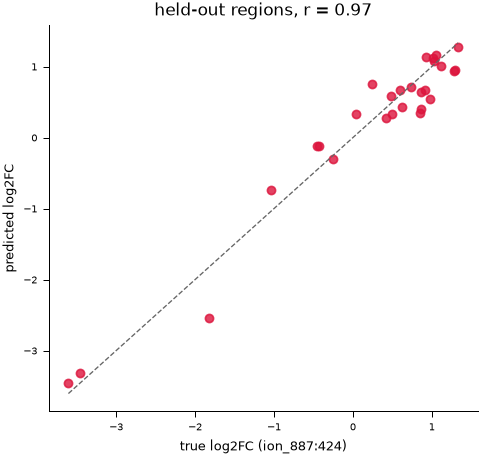

In [17]:
# unroll the per-lipid regression for ONE ion, fitting the WHOLE feature pipeline
# (MinMax -> NMF gene programs -> z-score) on the TRAINING regions only, so the held-out regions
# never shape the features they are scored on. no leakage.
region_idx = np.arange(len(genes))
tr, te = train_test_split(region_idx, test_size=0.25, random_state=SEED)
print(f"{len(tr)} training regions, {len(te)} held-out test regions (programs fit on train only)")

mm = MinMaxScaler().fit(genes.values[tr])                 # gene scaler: TRAIN regions only
Xg_all = np.clip(mm.transform(genes.values), 0, 1)   # held-out regions clip into the train range
nmf_tr = NMF(n_components=N_PROGRAMS, init="nndsvda", random_state=SEED, max_iter=500).fit(Xg_all[tr])
W = nmf_tr.transform(Xg_all)                              # program activity (test via train-fit model)
H = nmf_tr.components_
Wz = StandardScaler().fit(W[tr]).transform(W)             # z-score: TRAIN regions only

# a quick leak-free sweep to find the best-predicted ion to demonstrate on (the full table follows)
_scores, *_ = multimodal.predict_changes(genes, change, n_programs=N_PROGRAMS, test_size=0.25, random_state=SEED)
lipid0 = _scores.iloc[0]["lipid"]                         # the top-scoring ion
y0 = change[lipid0].to_numpy()

m0 = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=3,
                      subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                      random_state=SEED, objective="reg:squarederror")
m0.fit(Wz[tr], y0[tr])
pred0 = m0.predict(Wz[te])
r0 = pearsonr(pred0, y0[te])[0]
print(f"{nice(lipid0)} ({lipid0}): held-out Pearson r = {r0:.2f}")

fig, ax = plt.subplots(figsize=(4.2, 4.0))
ax.scatter(y0[te], pred0, s=24, c="crimson", alpha=0.8)
lim = [min(y0[te].min(), pred0.min()), max(y0[te].max(), pred0.max())]
ax.plot(lim, lim, ls="--", lw=0.8, c="0.4")
ax.set_xlabel(f"true log2FC ({nice(lipid0)})"); ax.set_ylabel("predicted log2FC")
ax.set_title(f"held-out regions, r = {r0:.2f}", fontsize=FS["m"])
plt.tight_layout(); plt.show()

**check:** the points cluster along the diagonal: regions where this ion rose in pregnancy are
regions the gene programs predicted it would rise. A solid positive test r says the transcriptome
carries real, generalisable information about where this lipid changes. Not every lipid is this
predictable, and that is itself a finding: some ions, including the headline myelin sphingolipid, have a
pregnancy change that is *not* readable from regional gene programs even though we can see it clearly in
space. Swap `lipid0` to `MYELIN_ION` and re-run this cell to watch the diagonal dissolve, a real, honest
negative result that the full sweep below puts in context.

Now we run the same loop for all 104 ions. The helper `cl.multimodal.predict_changes` does exactly what
we just unrolled, per ion, and on top of the test Pearson r it also computes, for free, the SHAP
program-importance we use in the next section.

In [18]:
# the helper fits the SAME leak-free pipeline (programs on train only) and one XGBoost per ion,
# and returns the mean |SHAP| program-importance matrix used in section 8. The W/H it returns are
# the leak-free programs, so the SHAP and gene-ontology reads below interpret exactly what was scored.
scores, shap_mat, W, H, nmf_model, tr, te = multimodal.predict_changes(
    genes, change, n_programs=N_PROGRAMS, test_size=0.25, random_state=SEED
)
n_good = int((scores["test_r"] > 0.3).sum())
print(f"ions with held-out Pearson r > 0.3: {n_good} of {len(scores)}")
print(f"mean held-out r across ions: {scores['test_r'].mean():.2f}")
print("\nbest-predicted ions:")
best_tbl = scores.head(6).copy()
best_tbl["lipid_name"] = best_tbl["lipid"].map(nice)
print(best_tbl[["lipid_name", "test_r"]].to_string(index=False))

ions with held-out Pearson r > 0.3: 85 of 104
mean held-out r across ions: 0.69

best-predicted ions:
 lipid_name   test_r
ion_887:424 0.973684
  PE O-39:7 0.972125
ion_758:510 0.971295
ion_534:296 0.964833
    PA 34:2 0.964579
ion_741:483 0.957031


**check:** a good fraction of the 104 ions reach test r > 0.3, and the mean test r is modest but
clearly positive. Read that carefully. It does not mean the genes "cause" the lipids: it means that,
across anatomy, where a lipid changes in pregnancy is partly predictable from the regional
transcriptome. The best-predicted ions include several sphingolipids and phospholipids that move
strongly with anatomy, the honest, expected result.

❓ **QUESTION.** A modest mean test r averaged across ions is unimpressive next to, say, predicting a
held-out pixel from its neighbours. Why might that be the *right* answer here rather than a failure?
(Hint: the gene matrix is a regional average from different mice, and a lipid is the end product of
enzymes, transport, and turnover, not a direct readout of one transcript.)

Look at the whole distribution of scores, not just the top. A histogram of the per-ion test r shows how
many ions the transcriptome predicts well versus poorly.

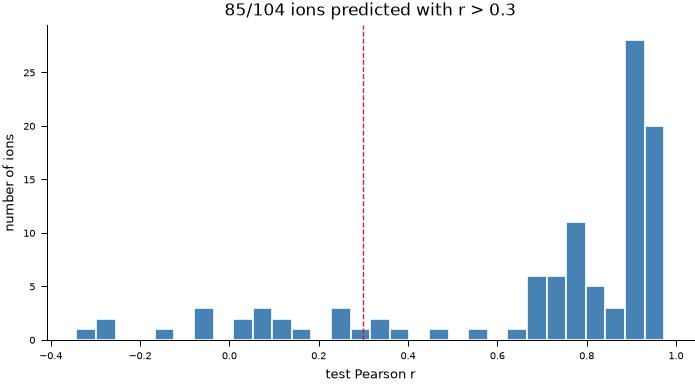

In [19]:
# distribution of per-ion test Pearson r
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(scores["test_r"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(0.3, ls="--", lw=0.8, c="crimson")
ax.set_xlabel("test Pearson r"); ax.set_ylabel("number of ions")
ax.set_title(f"{n_good}/{len(scores)} ions predicted with r > 0.3", fontsize=FS["m"])
plt.tight_layout(); plt.show()

## 8. SHAP: which gene program drives each prediction

A test r tells you a model predicts well. It does not tell you *why*, which program the model leaned on.
For that we use **SHAP**, SHapley Additive exPlanations. The idea comes from game theory. Imagine the
prediction for one region is a payout, and the features (the 20 gene programs) are players who cooperate
to produce it. SHAP asks, for each player, how much of the payout is fairly attributed to them, by
averaging the player's marginal contribution over every possible order in which the players could join
the game. The result is one signed number per feature per prediction, the SHAP value, and the SHAP
values for a region sum, with a baseline, exactly to the model's prediction for that region. So SHAP
decomposes each prediction into per-program contributions.

For tree models this averaging has a fast exact algorithm, TreeSHAP, built straight into XGBoost. We
take the absolute SHAP value of each program (we care about magnitude of influence, not sign), average
it across the regions, and get one importance number per program per ion. The helper already computed
this and handed it back as `shap_mat`, a programs x ions table.

🔬 **TASK.** Read out, for one ion, exactly how the helper got its SHAP numbers, using XGBoost's native
exact path. Then confirm it matches the helper.

In [20]:
# unroll TreeSHAP for ONE ion using XGBoost's exact pred_contribs path, on the leak-free programs
Wz = StandardScaler().fit(W[tr]).transform(W)     # z-score programs (fit on train), same as the helper
m0 = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=3,
                      subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                      random_state=SEED, objective="reg:squarederror")
m0.fit(Wz[tr], change[lipid0].to_numpy()[tr])

# pred_contribs=True returns exact TreeSHAP: one value per program + a final bias column
contribs = m0.get_booster().predict(xgb.DMatrix(Wz), pred_contribs=True)
contribs = contribs[:, :-1]                       # drop the last column (bias / base value)
shap_one = np.abs(contribs).mean(0)               # mean |SHAP| per program over all regions

top3 = np.argsort(shap_one)[::-1][:3]
for j in top3:
    print(f"  program{j+1}: mean |SHAP| = {shap_one[j]:.4f}")

print("\nmatches helper's shap_mat column?",
      np.allclose(shap_one, shap_mat[lipid0].to_numpy()))

  program4: mean |SHAP| = 0.4765
  program2: mean |SHAP| = 0.1495
  program15: mean |SHAP| = 0.1334

matches helper's shap_mat column? True


💡 **HINT.** `pred_contribs=True` is XGBoost's exact TreeSHAP. The last column it returns is the
base value (the model's average output), which is why we drop it before taking the mean absolute SHAP
per program.

Now aggregate across all ions. Averaging each program's mean-|SHAP| across the 104 ions gives the global
importance of each gene program for explaining the pregnancy lipidome change. The program at the top is
the one the models leaned on most, across all ions.

🔬 **TASK.** Rank the programs and plot the top ones.

most predictive gene programs (mean |SHAP| across all ions):
program4     0.513661
program15    0.241580
program2     0.240040
program1     0.137872
program18    0.136311
program5     0.117779


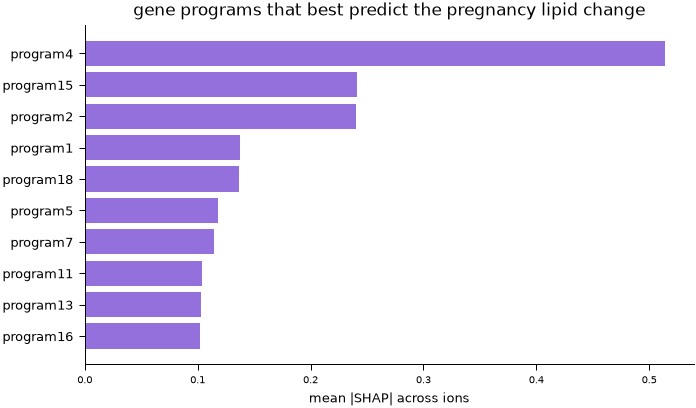

In [21]:
# aggregate program importance across all ions, then rank
prog_importance = shap_mat.mean(axis=1).sort_values(ascending=False)
print("most predictive gene programs (mean |SHAP| across all ions):")
print(prog_importance.head(6).to_string())

fig, ax = plt.subplots(figsize=(6, 3.6))
top = prog_importance.head(10)[::-1]
ax.barh(range(len(top)), top.values, color="mediumpurple")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=FS["s"])
ax.set_xlabel("mean |SHAP| across ions")
ax.set_title("gene programs that best predict the pregnancy lipid change", fontsize=FS["m"])
plt.tight_layout(); plt.show()

**check:** one program stands clearly at the top. It is the gene program the 104 models lean on
most when predicting where lipids change in pregnancy. The next question is the only one that matters
biologically: *which genes is that program made of?*

## 9. read the leading genes of the top program

A program is a recipe, a row of `H`, one non-negative weight per gene. The genes with the biggest
weights *define* the program. The helper `cl.multimodal.top_genes_for_program` sorts a program's row of
`H` and returns its leading genes.

🔬 **TASK.** Pull the leading genes of the top program.

In [22]:
# leading genes of the most predictive program (top program by SHAP)
top_prog_name = prog_importance.index[0]
top_prog_idx = int(top_prog_name.replace("program", "")) - 1
leading = multimodal.top_genes_for_program(H, genes, top_prog_idx, top=30)

print(f"{top_prog_name} is the top predictive program.")
print("its 20 leading genes:")
print(list(leading.head(20).index))
print("\nis Pparg (master lipid-metabolism regulator) among the top 30?", "Pparg" in leading.index)

program4 is the top predictive program.
its 20 leading genes:
['Lpar4', 'Ppp1r3c', 'Cpxm1', 'Fgd6', 'Ggta1', 'Cyp2d22', 'Pdgfrb', 'Scara3', 'Aldh1a1', 'Gjb6', 'Cdc42ep4', 'Axl', 'Stk17b', 'S100a4', 'Glipr2', 'Hmgcs2', 'Itih5', 'Slc7a2', 'Vim', 'Gstm1']

is Pparg (master lipid-metabolism regulator) among the top 30? False


💡 **HINT.** Look at that list. The most predictive program need not be the tidiest biology: its
top loadings are often a mix of one or two lipid-handling regulators, several region-specific markers,
and a string of uncharacterised clones. That is honest. A program can be a strong *predictor* without
being a clean, nameable *process*. We plot its recipe, then in the next section the gene ontology tests,
formally, which program carries a coherent biology.

🔬 **TASK.** Plot the leading-gene loadings so the recipe is visible.

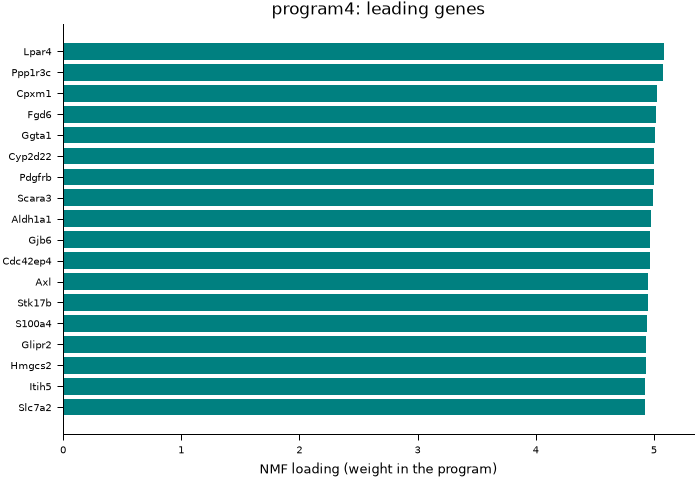

In [23]:
# the leading-gene loadings of the top program as a bar chart
fig, ax = plt.subplots(figsize=(6, 4.2))
lg = leading.head(18)[::-1]
ax.barh(range(len(lg)), lg.values, color="teal")
ax.set_yticks(range(len(lg))); ax.set_yticklabels(lg.index, fontsize=FS["xs"])
ax.set_xlabel("NMF loading (weight in the program)")
ax.set_title(f"{top_prog_name}: leading genes", fontsize=FS["m"])
plt.tight_layout(); plt.show()

❓ **QUESTION.** Any program here is a *correlative* predictor, not a proven cause. Its genes
co-vary with the lipid change across regions; they are not, on this evidence alone, switching the lipids
on. What experiment would you need to move from "predicts" to "causes"? (Hint: think perturbation, not
correlation.)

## 10. gene ontology: name the biology of a program

We have genes. We want biology. A list of gene symbols is not yet a story; **gene ontology** turns it
into one. The Gene Ontology is a controlled vocabulary of biological terms, organised into three
namespaces: biological process (what the gene helps *do*, like "myelination"), molecular function (the
biochemical activity), and cellular component (where in the cell it acts). Every gene is annotated to the
terms it participates in.

Enrichment asks a clean statistical question. Take a program's leading genes (the *study* set). Take all
the genes we measured (the *background*). For each ontology term, count how many study genes carry it
versus how many background genes do, and run a Fisher exact test: is this term over-represented in the
study set beyond chance? Because we test thousands of terms, we correct the p-values with
Benjamini-Hochberg, the same FDR control we used for the differential lipids. A term that survives is a
biological process the program's genes are genuinely about.

We run this with two tools. `mygene` converts gene *symbols* into the Entrez gene IDs that the ontology
files key on. `goatools` holds the ontology graph (`go-basic.obo`) and the gene-to-term annotations
(`gene2go`, filtered to mouse, taxid 10090) and runs the enrichment. We pre-downloaded both files into
`data/go/` so the notebook does not depend on a live download; the cell after this one shows the
download call you would use if the files were absent.

🔬 **TASK.** Load the ontology and the mouse annotations.

In [24]:
# load the pre-downloaded Gene Ontology graph and the mouse gene->term annotations
import io, contextlib
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.go_enrichment import GOEnrichmentStudy

GO_DIR = "../../data/go"
with contextlib.redirect_stdout(io.StringIO()):          # the loaders are chatty; quiet them
    godag = GODag(f"{GO_DIR}/go-basic.obo")
    anno = Gene2GoReader(f"{GO_DIR}/gene2go_mouse", taxids=[10090])
    ns2assoc = anno.get_ns2assc()

# fold the three namespaces' gene->term maps into one association dict
assoc = {}
for ns, d in ns2assoc.items():
    for gene_id, gos in d.items():
        assoc.setdefault(gene_id, set()).update(gos)
print(f"ontology terms: {len(godag):,}")
print(f"mouse genes with annotations: {len(assoc):,}")

../../data/go/go-basic.obo: fmt(1.2) rel(2026-05-19) 41,552 Terms


ontology terms: 41,552
mouse genes with annotations: 23,343


The cell below is the live-download version, kept for reference. If `data/go/` were empty you
would run this to fetch `go-basic.obo` and `gene2go` from the public servers, then filter `gene2go` to
mouse. It is illustrative only; we do not execute it, because the files are already on disk.

In [25]:
# ILLUSTRATIVE: how you would download the GO files if they were not already on disk.
# (Not executed; the files live in data/go/. The gene2go full file is ~10 GB decompressed,
#  so we filter it to mouse, taxid 10090, before using it.)
#
# from goatools.base import download_go_basic_obo
# download_go_basic_obo("data/go/go-basic.obo")
# # gene2go via HTTPS (the goatools FTP helper is brittle):
# #   curl -sSL -o gene2go.gz https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz
# #   gunzip gene2go.gz
# #   awk -F'\t' 'NR==1 || $1==10090' gene2go > data/go/gene2go_mouse
print("illustrative cell; the GO files are already in data/go/")

illustrative cell; the GO files are already in data/go/


Now the enrichment. We need Entrez IDs, so we convert symbols with `mygene`. The background is
every gene we measured (the 8460 in the matrix), which is the correct universe: we only ever could have
detected those genes, so they, not the whole genome, are the fair comparison.

🔬 **TASK.** Convert the background genes to Entrez IDs and build the enrichment study object. This
makes one network call to `mygene`.

In [26]:
# convert gene symbols -> Entrez IDs with mygene (one network call)
import mygene
mg = mygene.MyGeneInfo()

def symbols_to_entrez(symbols):
    res = mg.querymany(list(symbols), scopes="symbol", fields="entrezgene",
                       species="mouse", verbose=False)
    return {r["query"]: int(r["entrezgene"]) for r in res if "entrezgene" in r}

bg_map = symbols_to_entrez(genes.columns)                 # background = all measured genes
print(f"background genes mapped to Entrez: {len(bg_map)} of {genes.shape[1]}")

with contextlib.redirect_stdout(io.StringIO()):
    goe = GOEnrichmentStudy(list(bg_map.values()), assoc, godag,
                            propagate_counts=True, alpha=0.05, methods=["fdr_bh"])
print("enrichment study ready (background, associations, ontology loaded)")

background genes mapped to Entrez: 8022 of 8460


enrichment study ready (background, associations, ontology loaded)


We now have a function: hand it a program's leading genes, get back its significantly enriched
biological-process terms. We run it first on the top predictive program, then we scan the other top
programs, because the single most interpretable biology in this dataset can live in a slightly different
program, and finding it is part of the lesson: the *most predictive* program and the *most interpretable*
program need not be the same.

🔬 **TASK.** Run enrichment on the top program's leading genes.

In [27]:
def enriched_bp(program_idx, top=100):
    """Significantly enriched biological-process GO terms for a program's leading genes."""
    lead = multimodal.top_genes_for_program(H, genes, program_idx, top=top)
    study_map = symbols_to_entrez(lead.index)
    with contextlib.redirect_stdout(io.StringIO()):
        res = goe.run_study(list(study_map.values()))
    sig = [r for r in res if r.enrichment == "e" and r.NS == "BP" and r.p_fdr_bh < 0.05]
    sig = sorted(sig, key=lambda r: r.p_fdr_bh)
    return pd.DataFrame([(r.name, r.p_fdr_bh, r.ratio_in_study[0]) for r in sig],
                        columns=["GO term (BP)", "FDR", "study_genes"])

go_top = enriched_bp(top_prog_idx, top=100)
print(f"{top_prog_name}: {len(go_top)} enriched BP terms at FDR < 0.05")
print(go_top.head(8).to_string(index=False) if len(go_top) else "  (no term survives FDR < 0.05)")

program4: 44 enriched BP terms at FDR < 0.05
                              GO term (BP)      FDR  study_genes
                     developmental process 0.000965           58
                animal organ morphogenesis 0.001525           18
   regulation of anatomical structure size 0.002978           15
          multicellular organismal process 0.003490           47
        anatomical structure morphogenesis 0.008101           29
                        tube morphogenesis 0.010673           13
          anatomical structure development 0.010673           43
regulation of actin filament-based process 0.012098           13


💡 **HINT.** Do not be disappointed if the top predictive program returns few or no significant
terms. That is honest: a program whose top loadings are a lipid-metabolism regulator plus assorted region
markers and uncharacterised clones need not map onto one clean process, and the gene ontology refuses to
invent a story the annotations do not support. The model can lean on a program for prediction even when
that program is not a tidy biological process. So we scan the top predictive programs and find the one
with the *cleanest* biology, the one carrying the single strongest enriched term.

🔬 **TASK.** Scan the top predictive programs and keep the one with the strongest enriched term.

In [28]:
# scan the top predictive programs; record each one's strongest (lowest-FDR) BP term
rows = []
go_results = {}
for pname in prog_importance.head(8).index:
    pidx = int(pname.replace("program", "")) - 1
    df = enriched_bp(pidx, top=100)
    go_results[pname] = df
    if len(df):
        rows.append((pname, len(df), df["GO term (BP)"].iloc[0], float(df["FDR"].iloc[0])))
    else:
        rows.append((pname, 0, "-", np.nan))
scan = pd.DataFrame(rows, columns=["program", "n_sig_BP_terms", "top term", "top_FDR"])
print(scan.to_string(index=False))

# pick the most interpretable program: the one whose strongest term has the lowest FDR.
# (Term *count* favours vague catch-all terms; the single strongest term favours a specific,
#  coherent process, which is what we want to name.)
best_prog = scan.dropna(subset=["top_FDR"]).sort_values("top_FDR").iloc[0]["program"]
print(f"\nmost interpretable program: {best_prog}")
print(go_results[best_prog].head(8).to_string(index=False))

  program  n_sig_BP_terms              top term      top_FDR
 program4              44 developmental process 9.651598e-04
program15               0                     -          NaN
 program2               0                     -          NaN
 program1               0                     -          NaN
program18               0                     -          NaN
 program5              12           myelination 1.949845e-09
 program7               0                     -          NaN
program11               0                     -          NaN

most interpretable program: program5
                               GO term (BP)          FDR  study_genes
                                myelination 1.949845e-09           14
                          axon ensheathment 1.949845e-09           14
                    ensheathment of neurons 1.949845e-09           14
         central nervous system myelination 1.027667e-02            5
axon ensheathment in central nervous system 1.027667e-02       

**check:** one program should light up with a coherent, specific process at a strikingly low FDR,
the single strongest enriched term in the whole scan. In a clean run this is a **myelination /
ensheathment** program, its leading genes the classic oligodendrocyte transcripts. The cell below prints
that program's leading genes and the myelin transcripts among them so you can check it directly. If your
own run surfaces a different coherent program, read its top term and its leading genes and ask what
biology it names: that is the genuine, data-driven answer for *your* lipizones, and the reasoning is the
same.

🔬 **TASK.** Plot the enriched terms of the most interpretable program as a clean ontology bar chart.

2 gene programs have significant biological-process terms; showing each one.


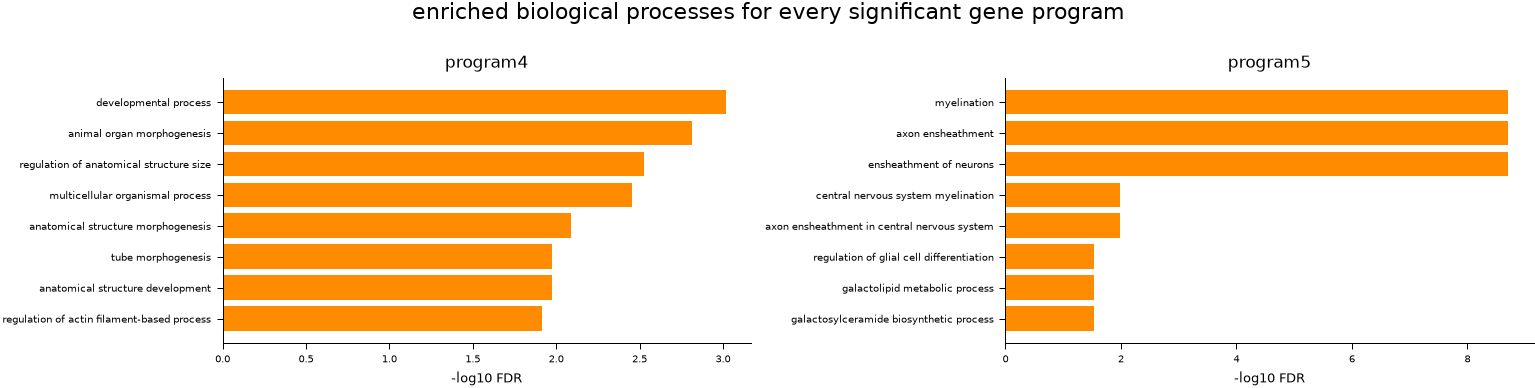

program5 top-20 leading genes: ['Hsd11b2', 'Ankub1', 'Tspan15', 'Depdc1b', 'Sall1', 'Clic4', 'Plxnb3', 'Padi2', 'Defb42', 'St6gal1', 'Ndrg1', 'Ttyh2', 'Cpm', 'Gjc2', 'Pcsk6', 'Unc5b', 'Lpar1', 'Rhou', 'BC051408', 'Carhsp1']
classic myelin transcripts (gene: rank by loading): {'Mobp': 45, 'Mag': 60, 'Aspa': 52, 'Plp1': 73, 'Mal': 113, 'Mog': 99, 'Mbp': 152}


In [29]:
# gene-ontology bars for EVERY program with significant BP terms, one module at a time
sig_progs = scan[scan['n_sig_BP_terms'] > 0]['program'].tolist()
print(f'{len(sig_progs)} gene programs have significant biological-process terms; showing each one.')
ncol = 2; nrow = int(np.ceil(max(len(sig_progs),1)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.3*nrow)); axes = np.atleast_1d(axes).ravel()
for ax, pname in zip(axes, sig_progs):
    g = go_results[pname].head(8)
    yv = (-np.log10(g['FDR'].clip(lower=1e-300)))[::-1]; labels = g['GO term (BP)'][::-1]
    ax.barh(range(len(yv)), yv, color='darkorange')
    ax.set_yticks(range(len(yv))); ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel('-log10 FDR'); ax.set_title(pname, fontsize=FS['m'])
for ax in axes[len(sig_progs):]: ax.axis('off')
plt.suptitle('enriched biological processes for every significant gene program', y=1.005)
plt.tight_layout(); plt.show()

# leading genes + classic myelin transcripts for the most interpretable program
best_idx = int(best_prog.replace('program', '')) - 1
best_leading = multimodal.top_genes_for_program(H, genes, best_idx, top=20)
print(f'{best_prog} top-20 leading genes:', list(best_leading.index))
prog_genes = multimodal.top_genes_for_program(H, genes, best_idx, top=H.shape[1])
myelin = [g for g in ['Mobp','Mag','Aspa','Plp1','Mal','Mog','Mbp'] if g in prog_genes.index]
print('classic myelin transcripts (gene: rank by loading):', {g: int(prog_genes.index.get_loc(g))+1 for g in myelin})

This closes a loop with the differential side of the course. The lipids that move most in
pregnancy include the myelin sphingolipids like `HexCer 42:2`, and if the most interpretable
transcriptional program is the one that builds myelin, then the lipids and the genes line up, from two independent experiments. Two modalities, measured years and labs apart, are
consistent with the same biology — a correlation across regions, not a demonstrated cause.

## 11. the negative control: a permutation null

Before we believe any of this, we owe ourselves a sanity check. A solid test r for the *best* ions
*feels* convincing. But with only about a hundred regions, could a model score that high by chance, just
by exploiting flexible trees on a small sample? The clean way to answer is a **permutation null**, and
it is worth understanding what that is, because it is the most honest tool in this whole notebook.

A permutation null builds, by brute force, the distribution of scores you would see *if your claim were
false*. Our claim is that a region's genes carry information about that region's lipid change. The null
hypothesis is the opposite: the gene programs and the lipid change have nothing to do with each other,
and any score we got was luck. To simulate that null world we **break the one link we claim is real**.
We keep the gene programs exactly as they are, but we *shuffle* each ion's change across regions, so
region A now wears region Q's lipid change. Everything else, the model, the split, the number of
features, stays identical, so the only thing destroyed is the gene-to-lipid correspondence. We refit and
re-score. Repeat the shuffle many times and you trace out the whole cloud of scores achievable by pure
chance: that cloud is the null distribution. The empirical p-value is just the fraction of shuffles that
matched or beat the real score, with the standard `(1 + count) / (n + 1)` form that never reports an
impossible zero. If the real score sits far to the right of the cloud, the signal is real.

🔬 **TASK.** Run the permutation null on the 12 best-predicted ions. Twenty shuffles.

In [30]:
# permutation null on the best-predicted ions: shuffle the target, re-fit, compare
N_PERM = 20
top_lipids = scores.head(12)["lipid"].tolist()
target_sub = change[top_lipids]

def mean_test_r(target_df, permute_rng=None):
    """Mean held-out Pearson r across the given ions; shuffle targets if permute_rng given."""
    rs = []
    for lip in target_df.columns:
        y = target_df[lip].to_numpy().copy()
        if permute_rng is not None:
            y = permute_rng.permutation(y)               # break region <-> change link
        m = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=3,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                             random_state=SEED, objective="reg:squarederror")
        m.fit(Wz[tr], y[tr])
        p = m.predict(Wz[te])
        rs.append(pearsonr(p, y[te])[0] if np.std(p) > 0 and np.std(y[te]) > 0 else 0.0)
    return float(np.mean(rs))

obs_r = mean_test_r(target_sub)                          # the real, observed mean r
perm_rng = np.random.default_rng(0)
perm_r = np.array([mean_test_r(target_sub, perm_rng) for _ in range(N_PERM)])

p_emp = (1 + np.sum(perm_r >= obs_r)) / (N_PERM + 1)
print(f"observed mean test r : {obs_r:.3f}")
print(f"permuted mean test r : range [{perm_r.min():.3f}, {perm_r.max():.3f}], mean {perm_r.mean():.3f}")
print(f"empirical p-value    : {p_emp:.4f}")

observed mean test r : 0.959
permuted mean test r : range [-0.068, 0.099], mean 0.007
empirical p-value    : 0.0476


🔬 **TASK.** Draw the null. The observed score should sit far to the right of the cloud of
permuted scores.

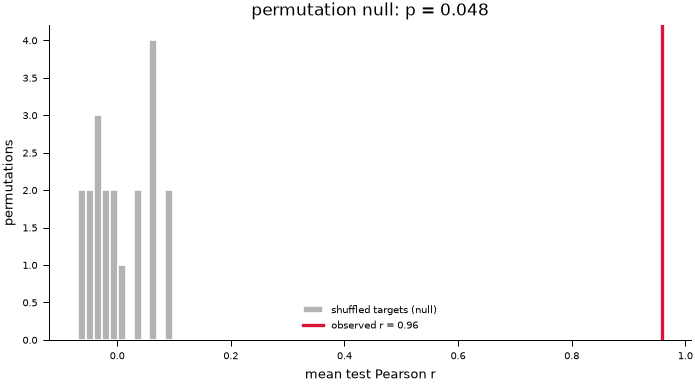

In [31]:
# the negative-control figure: null distribution vs the observed score
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(perm_r, bins=12, color="0.7", edgecolor="white", label="shuffled targets (null)")
ax.axvline(obs_r, color="crimson", lw=2, label=f"observed r = {obs_r:.2f}")
ax.set_xlabel("mean test Pearson r"); ax.set_ylabel("permutations")
ax.set_title(f"permutation null: p = {p_emp:.3f}", fontsize=FS["m"])
ax.legend(fontsize=FS["xs"])
plt.tight_layout(); plt.show()

**check:** the observed mean test r (over the 12 best-predicted ions) sits to the right of the
permuted null, which clusters near zero. Shuffling the region labels destroyed the signal: the genes
predict the lipid change because of the *real* region-to-region correspondence, not because flexible
trees can fit any small table. With more permutations the p-value would tighten further; 20 is enough to
make the point in class.

❓ **QUESTION.** We shuffled each ion's change *across regions* and kept the gene programs fixed. Why is
that the right thing to break, rather than, say, shuffling the gene values? (Hint: which correspondence
is the scientific claim?)

## 12. assemble the figure yourself

There is no single charted recipe for the final figure, and that is on purpose. You have already
produced every panel a paper on this analysis would want, each as its own clean figure above:

- the spatial myelin lipid `HexCer 42:2` on both sections, beside its borrowed `Mog` transcript (section 2.1),
- the per-pixel cell-type territory map (section 2.2),
- the lipizone x cell-type reciprocal-enrichment heatmap (section 2.3),
- the per-region change matrix and the per-ion test-r distribution (sections 3 and 7),
- the SHAP program-importance ranking and the leading genes of the top program (sections 8 and 9),
- the gene-ontology bar chart of the most interpretable program (section 10),
- the permutation-null control (section 11).

🔬 **TASK.** Pick the panels that tell *your* story, export each to a vector PDF (`fig.savefig(...)`,
the lab default keeps text editable and scatter rasterised), then open them in Illustrator (or Inkscape)
and compose the multi-panel figure by hand: align the panels, unify the fonts, add the A/B/C/D letters,
trim redundant colorbars. Real figures are assembled this way, one deliberate decision at a time, not
emitted by a single cell. The science is done; the layout is now a craft choice that is yours to make.

## what you built

You integrated two experiments that never touched the same tissue, your MALDI lipidome and the Allen
MERFISH transcriptome, through the one thing they share: the same 3D Allen coordinate space. You did it
at two granularities of one gene-to-lipid question.

The fine, per-pixel way came first. You built a cKDTree on the MERFISH cell coordinates, queried every
cell within a small ball of each MSI pixel, and borrowed their genes (averaged) and their cell type
(majority vote). Only a fraction of pixels matched at the paper's 50 um, rising at 100 um, because the MSI plane only
overlaps the discrete MERFISH coronal sections, and that is the honest geometry of the match. The payoff
was visual and immediate: a borrowed `Mog` myelin transcript tracked the measured `HexCer 42:2` myelin
lipid pixel for pixel, a per-pixel cell-type territory map placed oligodendrocytes on the white-matter
tracts, and a lipizone x cell-type reciprocal-enrichment heatmap showed that lipid territories are very
often cell-type territories.

The coarse, per-region way did the rest. You reduced both modalities to the named Allen region and asked
a clean question: do a region's genes predict where its lipidome changes in pregnancy? You built the
per-region lipid-change matrix, joined the region-averaged gene expression, compressed 8460 genes into 20
NMF gene programs, fit one gradient-boosted tree per ion, and scored it honestly on held-out regions. A
good fraction of ions reached test r > 0.3, so the transcriptome carries real spatial information about
the lipid change. SHAP told you which program each model leaned on, gene ontology named the most
coherent program, and a permutation null confirmed the signal was real, not a small-sample artefact:
shuffling the region labels collapsed the score to zero.

The closing insight is the one to carry forward, and the two granularities tell it in unison. At the
pixel level, oligodendrocyte territories, the borrowed `Mog` gene, and the `HexCer 42:2` lipid all fall
on the same white matter. At the region level, the lipids that move most in pregnancy include the myelin
sphingolipids, and when the gene program that best predicts where the lipidome changes is the program
that builds myelin, two modalities measured years and labs apart point at the same biology, whether you
read it pixel by pixel or region by region. Because these are *your* lipizones and *your* fold changes,
the exact numbers are yours alone, but the shape of the story is robust. That is what integration by
shared coordinates buys you: not proof of cause, but a strong, testable hypothesis about which genes to
perturb next.